Notebook for the course [Master Hyperparameter Optimization for Tabular Learning](http://www.trainindata.com/p/master-hyperparameter-optimization-for-tabular-learning)

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import gaussian_kde

OUTPUT_DIR = Path("for-slides") if Path("for-slides/bayesian-optimization/").is_dir() else Path.cwd()

## Univariate Gaussian

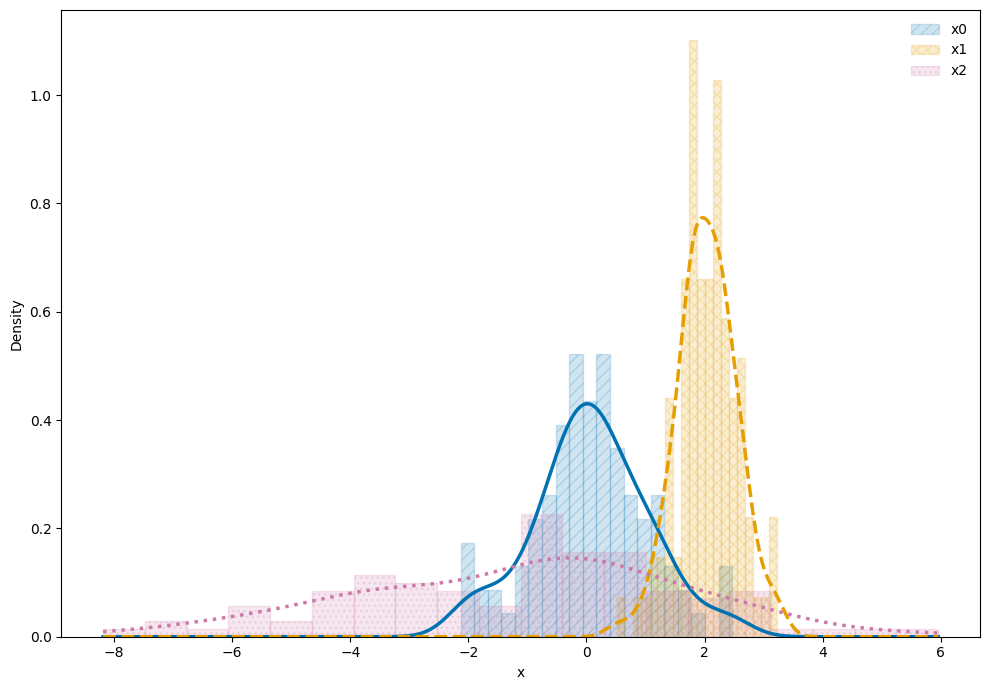

In [2]:
np.random.seed(10)

n = 100

x0 = np.random.normal(loc=0.0, scale=1.0, size=n)
x1 = np.random.normal(loc=2, scale=0.5, size=n)
x2 = np.random.normal(loc=-1, scale=3, size=n)

# Colorblind-friendly colors, reinforced by hatches and line styles for B&W print.
series = [
    (x0, "x0", "#0072B2", "///", "-"),
    (x1, "x1", "#E69F00", "xxx", "--"),
    (x2, "x2", "#CC79A7", "...", ":"),
]

fig, ax = plt.subplots(figsize=(10, 7))
x_grid = np.linspace(min(map(np.min, (x0, x1, x2))),
                     max(map(np.max, (x0, x1, x2))), 500)

for values, label, color, hatch, linestyle in series:
    ax.hist(values, bins=20, density=True, alpha=0.18, color=color,
            edgecolor=color, linewidth=1.0, hatch=hatch, label=label)
    ax.plot(x_grid, gaussian_kde(values)(x_grid), color=color,
            linestyle=linestyle, linewidth=2.5)

ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "univariate_gaussian_distributions.png",
            dpi=320, bbox_inches="tight")
plt.show()

## Multivariate Gaussian

In [3]:
domain =10
mean = 0
variance = 1

np.arange(-domain+mean, domain+mean, variance)

array([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,
         3,   4,   5,   6,   7,   8,   9])

In [4]:
def np_bivariate_normal_pdf(domain, mean, variance):
  X = np.arange(-domain+mean, domain+mean, variance)
  Y = np.arange(-domain+mean, domain+mean, variance)
  X, Y = np.meshgrid(X, Y)
  R = np.sqrt(X**2 + Y**2)
  Z = ((1. / np.sqrt(2 * np.pi)) * np.exp(-.5*R**2))
  return X+mean, Y+mean, Z


def plt_plot_bivariate_normal_pdf(x, y, z, filename):
  fig = plt.figure(figsize=(12, 6))
  ax = fig.add_subplot(projection='3d')
  ax.plot_surface(x, y, z, 
                  cmap=cm.cividis,
                  linewidth=0, 
                  antialiased=True)
  ax.set_xlabel('x1', labelpad=8)
  ax.set_ylabel('x2', labelpad=8)
  ax.set_zlabel('Density', labelpad=12)
  fig.subplots_adjust(left=0.02, right=0.88, bottom=0.06, top=0.98)
  fig.savefig(OUTPUT_DIR / filename, dpi=320, bbox_inches='tight')
  plt.show()

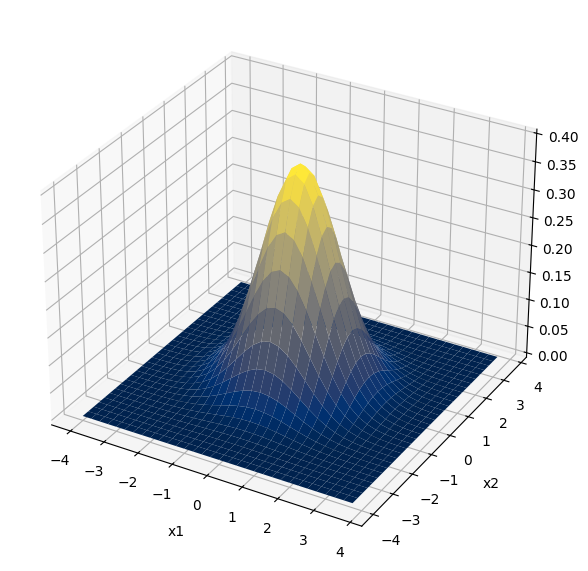

In [5]:
plt_plot_bivariate_normal_pdf(
    *np_bivariate_normal_pdf(4, 0, 0.25),
    filename="bivariate_gaussian_symmetric_surface.png",
)

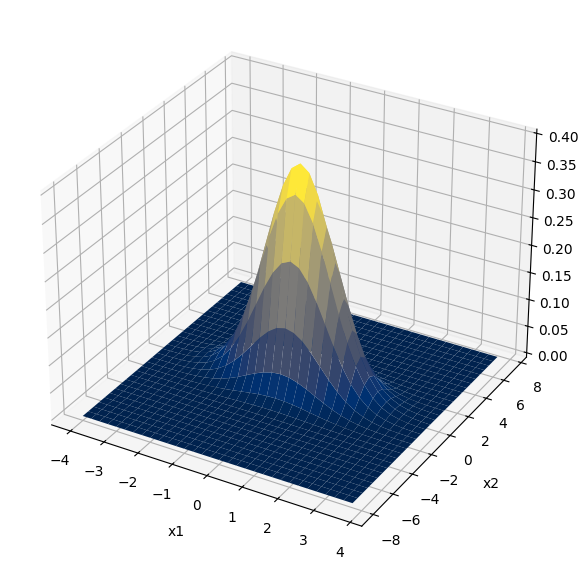

In [6]:
def np_bivariate_normal_pdf(domain, mean, variance):
  X = np.arange(-domain+mean, domain+mean, variance)
  Y = 2*X
  X, Y = np.meshgrid(X, Y)
  R = np.sqrt(X**2 + Y**2)
  Z = ((1. / np.sqrt(2 * np.pi)) * np.exp(-.5*R**2))
  return X+mean, Y+mean, Z

plt_plot_bivariate_normal_pdf(
    *np_bivariate_normal_pdf(4, 0, 0.25),
    filename="bivariate_gaussian_stretched_surface.png",
)